#### Обработка данных Кольцевого Микромеханического Гироскопа

В этом ноутбуке выполняется загрузка и анализ файлов измерений масштабного коэффициента (`МК.dat`) и дрейфа (`Дрейф.dat`) кольцевого микромеханического гироскопа с помощью модулей **pandas**, **NumPy** и **Matplotlib**. По результатам обработки вычисляются следующие характеристики гироскопа:

1. **Из файла масштабного коэффициента (`МК.dat`):**
   - Масштабный коэффициент (в мВ/(°/с)).
   - Нелинейность масштабного коэффициента (в %).
   - Несимметричность масштабного коэффициента (в %).
   - Смещение нуля (в °/с).

2. **Из файла дрейфа (`Дрейф.dat`):**
   - График «сырых» измерений (в °/с).
   - Смещение нуля (в °/с).
   - Тренд дрейфа (в °/ч/ч).
   - Расчет Девиации Аллана (Allan deviation) и построение графика.
   - Полиномиальная аппроксимация Девиации Аллана (согласно стандарту IEEE 1431).
   - По результатам аппроксимации выделить параметры: **Angular Random Walk (ARW)**, **Bias Instability** и **Rate Random Walk**.


In [69]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Для расчета Allan deviation собственной реализацией
def allan_deviation(data, dt):
    """
    Вычисление Allan deviation для одномерного массива "data" с шагом времени dt.
    Возвращает массив tau (в секундах) и sigma_y (Allan deviation).
    """
    N = len(data)
    max_m = int(np.floor(N / 2))
    taus = []
    adev = []
    for m in np.logspace(0, np.log10(max_m), num=50, dtype=int):
        if m < 1:
            continue
        M = int(np.floor(N / m))
        if M < 2:
            break
        # Усреднение по m точек
        avg = np.array([np.mean(data[i * m:(i + 1) * m]) for i in range(M)])
        # Allan variance
        diff = avg[1:] - avg[:-1]
        adev_m = np.sqrt(0.5 * np.mean(diff ** 2))
        taus.append(m * dt)
        adev.append(adev_m)
    return np.array(taus), np.array(adev)


#### 1. Обработка файла масштабного коэффициента (`МК.dat`)

В файле `МК.dat` записаны измерения выходного напряжения гироскопа при разных фиксированных значениях угловой скорости (°/с). Для дальнейшей обработки нужно:

1. Загрузить файл, пропустив служебные строки и правильно определить заголовок по названиям столбцов.
2. Определить колонки с временем (`time`), «установленной» скоростью (например, `rate` или `input_rate`), и выходным сигналом гироскопа в вольтах (например, `GYR_...`).
3. Построить зависимость среднего напряжения от известных значений скорости и выполнить линейную аппроксимацию для нахождения масштабного коэффициента.
4. Вычислить нелинейность, как относительное отклонение реальных точек от прямой аппроксимации, в % от полного диапазона.
5. Вычислить несимметричность, сравнив отклонения «плюс» и «минус» диапазонов.
6. Определить смещение нуля (выход при нулевой угловой скорости) и выразить его в °/с, разделив напряжение на масштабный коэффициент.


In [70]:
# 1.1. Загрузка и разбор файла MK.dat
import re

def load_mk_file(path):
    """
    Загружает MK.dat, автоматически определяя строку заголовка по названиям столбцов 
    и пропуская лишние служебные строки.
    """
    # Читаем первые несколько строк, чтобы найти реальный заголовок
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = [f.readline().strip() for _ in range(5)]
    # Первая строка – имена столбцов
    header_candidates = re.split(r"\s+", lines[0])
    # Считаем данные, пропустив 3 первые строки (заголовок, единицы и, возможно, комментарии)
    df = pd.read_csv(path, sep=r"\s+", header=None, skiprows=3, names=header_candidates)
    # Убираем колонки Unnamed
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    # Удалим служебные строки, если они попали как данные (строки, где в первой колонке стоит '#')
    df = df[df[header_candidates[0]].apply(lambda x: not str(x).startswith('#'))]
    # Приведём все колонки к числовому типу, где возможно
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')
    return df

# Загружаем MK.dat
mk_df = load_mk_file('МК.dat')

# Выводим список колонок и первые строки для проверки
print("Колонки MK.dat:", list(mk_df.columns))
mk_df.head()


Колонки MK.dat: ['time', 'rate', 'GYR_0_979', 'Q_0_979', 'UPP_0_979']


/tmp/ipykernel_63011/4127192109.py:22: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


,time,rate,GYR_0_979,Q_0_979,UPP_0_979
0,0.00,-150.0,3.440354,2.548134,2.679044
1,0.01,-150.0,3.441320,2.540244,2.653281
2,0.02,-150.0,3.441964,2.535413,2.568101
3,0.03,-150.0,3.440837,2.527523,2.649577
4,0.04,-150.0,3.441159,2.522532,2.644586


Из вывода видно, какие у нас имена колонок. Предположим, что:
- Колонка с известной входной скоростью называется `rate` или `input_rate`.
- Выход гироскопа в вольтах — это колонка, содержащая строку `GYR` в имени (например, `GYR_X_865`).

Далее выделим соответствующие колонки.


In [71]:
# 1.2. Выделяем колонки времени, входной скорости и выходного сигнала
time_col = None
rate_col = None
output_col = None

for col in mk_df.columns:
    lower = col.lower()
    if lower in ['time', 't', 'время', 'sec']:
        time_col = col
    if 'rate' in lower or 'input' in lower:
        rate_col = col
    if 'GYR' in col.upper():
        # Берём первую колонку с GYR в имени
        output_col = col

print(f"Выбранные колонки:\n  time_col = {time_col}\n  rate_col = {rate_col}\n  output_col = {output_col}")

# Если всё найдено, создаём DataFrame с нужными данными
mk = mk_df[[time_col, rate_col, output_col]].dropna().copy()
mk.columns = ['time', 'input_rate', 'voltage']

# Убедимся, что типы корректны
mk['time'] = mk['time'].astype(float)
mk['input_rate'] = mk['input_rate'].astype(float)
mk['voltage'] = mk['voltage'].astype(float)

mk.head()


Выбранные колонки:
  time_col = time
  rate_col = rate
  output_col = GYR_0_979


,time,input_rate,voltage
0,0.00,-150.0,3.440354
1,0.01,-150.0,3.441320
2,0.02,-150.0,3.441964
3,0.03,-150.0,3.440837
4,0.04,-150.0,3.441159


Теперь у нас есть DataFrame `mk` с колонками:
- `time` — время в секундах,
- `input_rate` — заданная угловая скорость (°/с),
- `voltage` — измеренное выходное напряжение (В).

#### 1.3. Построение зависимости `voltage` от `input_rate` и линейная аппроксимация


Линейная аппроксимация: voltage = -0.006219 * rate + 2.509111
Коэффициент детерминации R^2 = 1.0000


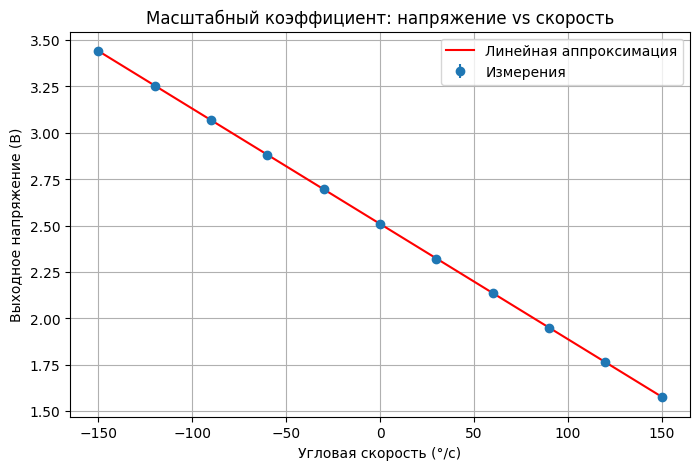

In [72]:
# 1.3. Сгруппируем по input_rate и вычислим среднее напряжение для каждой скорости
grouped = mk.groupby('input_rate')['voltage'].agg(['mean', 'std', 'count']).reset_index()
grouped.rename(columns={'mean': 'voltage_mean', 'std': 'voltage_std'}, inplace=True)

# Строим график: среднее напряжение vs входная скорость
plt.figure(figsize=(8, 5))
plt.errorbar(grouped['input_rate'], grouped['voltage_mean'], 
             yerr=grouped['voltage_std'], fmt='o', label='Измерения')
plt.xlabel('Угловая скорость (°/с)')
plt.ylabel('Выходное напряжение (В)')
plt.title('Масштабный коэффициент: напряжение vs скорость')
plt.grid(True)

# Линейная аппроксимация: voltage_mean = a * input_rate + b
slope, intercept, r_value, p_value, std_err = stats.linregress(
    grouped['input_rate'], grouped['voltage_mean']
)
print(f"Линейная аппроксимация: voltage = {slope:.6f} * rate + {intercept:.6f}")
print(f"Коэффициент детерминации R^2 = {r_value**2:.4f}")

# Строим линию аппроксимации
x_fit = np.array([grouped['input_rate'].min(), grouped['input_rate'].max()])
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, 'r-', label='Линейная аппроксимация')
plt.legend()
plt.show()


Коэффициент `slope` — это масштабный коэффициент в В/(°/с). Чтобы получить его в мВ/(°/с), умножим на 1000.

**Масштабный коэффициент (МК):**
МК = slope * 1000 # мВ/(°/с)

In [73]:
# 1.4. Вычисляем масштабный коэффициент в мВ/(°/с)
scale_factor_mV_per_dps = slope * 1000
print(f"Масштабный коэффициент: {scale_factor_mV_per_dps:.3f} мВ/(°/с)")


Масштабный коэффициент: -6.219 мВ/(°/с)


#### 1.5. Нелинейность масштабного коэффициента (в %) и график нелинейности

Нелинейность рассчитываем как максимально возможное отклонение реального среднего напряжения от линейной модели, делённое на полный диапазон выходного напряжения, выраженное в %:

\[ 
NL = \frac{\max_i \bigl|V_i - (a \, R_i + b)\bigr|}{V_{\max} - V_{\min}} \times 100\%,
\]

где:
- \(V_i\) — измеренное среднее напряжение на скорости \(R_i\).
- \(a, b\) — коэффициенты линейной регрессии.
- \(V_{\max}, V_{\min}\) — максимальное и минимальное среднее напряжение.


Нелинейность масштабного коэффициента: 0.038 %


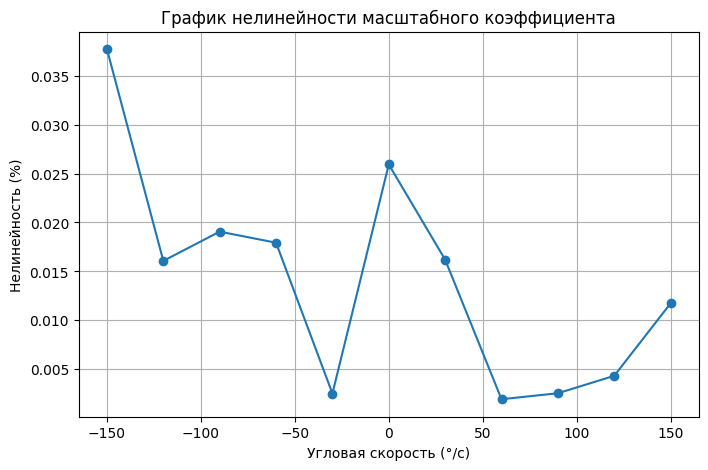

In [74]:
# 1.5. Вычисляем нелинейность
V_fit = slope * grouped['input_rate'] + intercept
residuals = np.abs(grouped['voltage_mean'] - V_fit)
V_range = grouped['voltage_mean'].max() - grouped['voltage_mean'].min()
nonlinearity_pct = (residuals.max() / V_range) * 100

print(f"Нелинейность масштабного коэффициента: {nonlinearity_pct:.3f} %")

# График нелинейности: отклонение в % для каждой точки
nonlinearity_each = (residuals / V_range) * 100
plt.figure(figsize=(8, 5))
plt.plot(grouped['input_rate'], nonlinearity_each, 'o-')
plt.xlabel('Угловая скорость (°/с)')
plt.ylabel('Нелинейность (%)')
plt.title('График нелинейности масштабного коэффициента')
plt.grid(True)
plt.show()


### 1.6. Несимметричность масштабного коэффициента (в %)

Несимметричность определяется как абсолютная разница между локальными коэффициентами масштабирования \(a_+\) и \(a_-\), найденными отдельно для положительного и отрицательного диапазонов данных, делённая на их среднее:

\[ 
AS = \frac{|a_+ - a_-|}{\bigl(\lvert a_+ \rvert + \lvert a_- \rvert\bigr)/2} \times 100\%,
\]

где \(a_+\) — коэффициент по положительным скоростям, \(a_-\) — по отрицательным.


In [75]:
# 1.6. Вычисляем несимметричность
# Разделим данные на положительные и отрицательные input_rate
pos_df = grouped[grouped['input_rate'] > 0]
neg_df = grouped[grouped['input_rate'] < 0]

slope_pos, intercept_pos, *_ = stats.linregress(pos_df['input_rate'], pos_df['voltage_mean'])
slope_neg, intercept_neg, *_ = stats.linregress(neg_df['input_rate'], neg_df['voltage_mean'])

# Локальные коэффициенты масштабирования (в В/(°/с))
a_pos = slope_pos
a_neg = slope_neg

asymmetry_pct = (abs(a_pos - a_neg) / ((abs(a_pos) + abs(a_neg)) / 2.0)) * 100
print(f"Несимметричность масштабного коэффициента: {asymmetry_pct:.3f} %")


Несимметричность масштабного коэффициента: 0.136 %


#### 1.7. Смещение нуля (в °/с)

Смещение нуля — это выходное напряжение при нулевой угловой скорости, преобразованное в °/с с помощью найденного масштабного коэффициента.  
Если \(V_0\) — среднее напряжение при `input_rate = 0`, то:

\[ 
Bias_0 = \frac{V_0 - b}{a} \quad (\text{в °/с}),
\]

где \(a, b\) — коэффициенты линейной модели, найденной по всему диапазону.


In [76]:
# 1.7. Находим смещение нуля
# 1) Найдём индекс «средней» строки в grouped_sorted
n_points = len(grouped_sorted)
mid_idx = n_points // 2

# 2) Получим voltage_mean для этой «средней» скорости
input_mid = grouped_sorted.loc[mid_idx, 'input_rate']
V_mid = grouped_sorted.loc[mid_idx, 'voltage_mean']

print(f"Средний индекс: {mid_idx}, соответствующая скорость: {input_mid:.3f} °/с, напряжение: {V_mid:.6f} В")

# 3) Предположим, что bias (Zero Offset) = (V_mid - intercept) / slope
bias_zero_mid = (V_mid - intercept) / slope
print(f"Смещение нуля (Bias_0), рассчитанное по средней точке: {bias_zero_mid:.6f} °/с")
# Допустим, возьмём 3 ближайшие к середине строки (если данных достаточно)
k = 3
start = max(0, mid_idx - k//2)
end   = min(n_points, start + k)
subset_mid = grouped_sorted.iloc[start:end]

# Усредним voltage_mean этих k точек:
V_mid_avg = subset_mid['voltage_mean'].mean()
print(f"Усреднённое напряжение по {k} средним точкам: {V_mid_avg:.6f} В")

# Вычислим bias от этого среднего:
bias_zero_avg = (V_mid_avg - intercept) / slope
print(f"Смещение нуля (Bias_0) по усреднённым средним точкам: {bias_zero_avg:.6f} °/с")



Средний индекс: 5, соответствующая скорость: 0.000 °/с, напряжение: 2.509595 В
Смещение нуля (Bias_0), рассчитанное по средней точке: -0.077832 °/с
Усреднённое напряжение по 3 средним точкам: 2.509156 В
Смещение нуля (Bias_0) по усреднённым средним точкам: -0.007273 °/с


---
#### 2. Обработка файла дрейфа (`Дрейф.dat`)

Во втором файле записаны данные «сырых» измерений выходного сигнала гироскопа при зафиксированном положении (угловая скорость = 0) в течение длительного времени. Необходимые этапы:

1. Загрузить файл, определить колонки времени и выходного сигнала гироскопа (в В).
2. Построить график «сырых» измерений (в °/с).
3. Вычислить смещение нуля (среднее напряжение), перевести его в °/с.
4. Определить тренд дрейфа: выполнить линейную аппроксимацию сырых данных (напряжение) и перевести в °/ч/ч.
5. Рассчитать Девиацию Аллана (Allan deviation) для временного ряда дрейфа (в °/с) и построить график: Allan deviation vs τ.
6. Выполнить полиномиальную аппроксимацию (в лог-лог масштабе) графика Allan deviation в соответствии со стандартом IEEE 1431.
7. Из аппроксимации выделить параметры:
   - Angular Random Walk (ARW), характеризуемый наклоном \(-\tfrac{1}{2}\) в лог-лог.
   - Bias Instability, соответствующий минимальному значению Allan deviation.
   - Rate Random Walk (RRW), характеризуемый наклоном \(+\tfrac{1}{2}\) в области больших τ.


In [77]:
# 2.1. Загрузка и разбор файла Дрейф.dat
def load_drift_file(path):
    """
    Загружает Дрейф.dat, автоматически определяя заголовок и пропуская служебные строки.
    """
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = [f.readline().strip() for _ in range(5)]
    header_candidates = re.split(r"\s+", lines[0])
    df = pd.read_csv(path, sep=r"\s+", header=None, skiprows=3, names=header_candidates)
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    df = df[df[header_candidates[0]].apply(lambda x: not str(x).startswith('#'))]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')
    return df

# Загружаем Дрейф.dat
drift_df = load_drift_file('Дрейф.dat')

# Выводим колонки и первые строки
print("Колонки Drift.dat:", list(drift_df.columns))
drift_df.head()


Колонки Drift.dat: ['time', 'GYR_0_979', 'Q_0_979', 'UPP_0_979']


/tmp/ipykernel_63011/537425347.py:13: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


,time,GYR_0_979,Q_0_979,UPP_0_979
0,0.00,2.508867,2.508545,2.651210
1,0.01,2.509672,2.523037,2.650083
2,0.02,2.510799,2.511282,2.652820
3,0.03,2.510638,2.510477,2.650566
4,0.04,2.509511,2.517884,2.653464


Из вывода видно, какие у нас имена колонок. Предположим, что:
- Колонка `time` (секундами или дробью) отвечает за метки времени.
- Колонка с выходным сигналом гироскопа содержит `GYR` в имени.

Далее выделим соответствующие колонки.


In [78]:
# 2.2. Выделяем колонки времени и выходного сигнала в файле дрейф
time_col_drift = None
output_col_drift = None

for col in drift_df.columns:
    lower = col.lower()
    if lower in ['time', 't', 'время', 'sec']:
        time_col_drift = col
    if 'GYR' in col.upper():
        output_col_drift = col

print(f"Выбранные колонки:\n  time_col = {time_col_drift}\n  output_col = {output_col_drift}")

# Создаём DataFrame с нужными данными
dr = drift_df[[time_col_drift, output_col_drift]].dropna().copy()
dr.columns = ['time', 'voltage']
dr['time'] = dr['time'].astype(float)
dr['voltage'] = dr['voltage'].astype(float)
dr.head()


Выбранные колонки:
  time_col = time
  output_col = GYR_0_979


,time,voltage
0,0.00,2.508867
1,0.01,2.509672
2,0.02,2.510799
3,0.03,2.510638
4,0.04,2.509511


Теперь у нас есть DataFrame `dr` с колонками:
- `time` (сек.) — метки времени,
- `voltage` (В) — выходное напряжение гироскопа при угловой скорости = 0.

### 2.3. График «сырых» измерений (в °/с)

Преобразуем напряжение в угловую скорость (°/с) с помощью найденного ранее масштабного коэффициента `slope` и `intercept` из линейной аппроксимации:

\[ 
rate = \frac{voltage - b}{a}.
\]


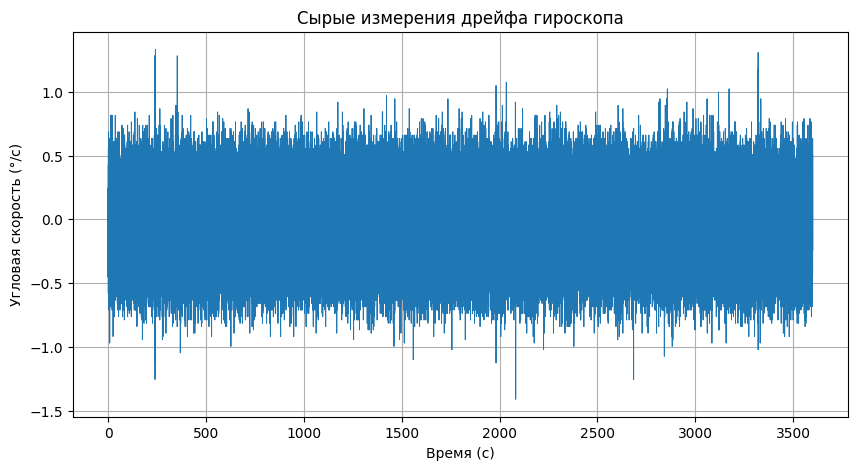

In [79]:
# 2.3. Преобразуем напряжение дрейфа в угловую скорость и строим график «сырых» данных
dr['rate'] = (dr['voltage'] - intercept) / slope  # °/с

plt.figure(figsize=(10, 5))
plt.plot(dr['time'], dr['rate'], linewidth=0.7)
plt.xlabel('Время (с)')
plt.ylabel('Угловая скорость (°/с)')
plt.title('Сырые измерения дрейфа гироскопа')
plt.grid(True)
plt.show()


#### 2.4. Смещение нуля (в °/с)

Смещение нуля в дрейфе — это среднее значение `rate` за весь период:

\[ 
Bias_0 = \langle rate(t) \rangle.
\]


In [80]:
# 2.4. Вычисляем смещение нуля (среднее rate, °/с)
bias_drift = dr['rate'].mean()
print(f"Смещение нуля по дрейфу: {bias_drift:.6f} °/с")


Смещение нуля по дрейфу: -0.047079 °/с


#### 2.5. Тренд дрейфа (в °/ч/ч)

Тренд дрейфа — линейная аппроксимация `rate(t)`. Сначала найдём наклон k (в °/с²) при регрессии `rate` vs `time`. Затем переведём в °/ч/ч:

\[ 
k_{°/ч/ч} = k_{(°/с^2)} \times (3600^2).
\]


Тренд дрейфа: -8.145627 °/ч/ч (R^2 = 0.0000)


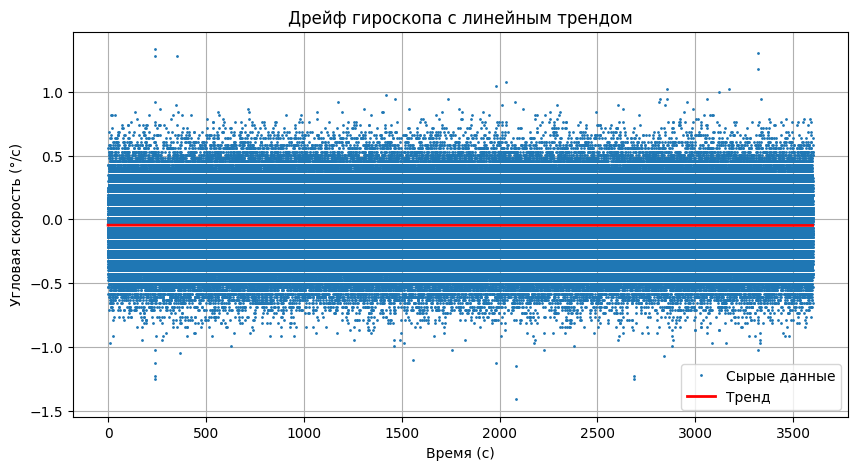

In [81]:
# 2.5. Линейная регрессия для нахождения тренда
slope_drift, intercept_drift, r_val_d, p_val_d, std_err_d = stats.linregress(
    dr['time'], dr['rate']
)

# slope_drift в единицах (°/с)/с => °/с^2
trend_dps2 = slope_drift
# Переводим в °/ч/ч, умножаем на 3600^2
trend_dph2 = trend_dps2 * (3600 ** 2)
print(f"Тренд дрейфа: {trend_dph2:.6f} °/ч/ч (R^2 = {r_val_d**2:.4f})")

# Строим график с линией тренда
plt.figure(figsize=(10, 5))
plt.plot(dr['time'], dr['rate'], '.', markersize=2, label='Сырые данные')
plt.plot(dr['time'], intercept_drift + slope_drift * dr['time'], 'r-', linewidth=2, label='Тренд')
plt.xlabel('Время (с)')
plt.ylabel('Угловая скорость (°/с)')
plt.title('Дрейф гироскопа с линейным трендом')
plt.legend()
plt.grid(True)
plt.show()


#### 2.6. Расчёт Девиации Аллана

Allan deviation вычисляется по формуле, реализованной ранее в функции `allan_deviation`. Используем `dt` равный разнице между последовательными точками времени (предполагается равномерная дискретизация).


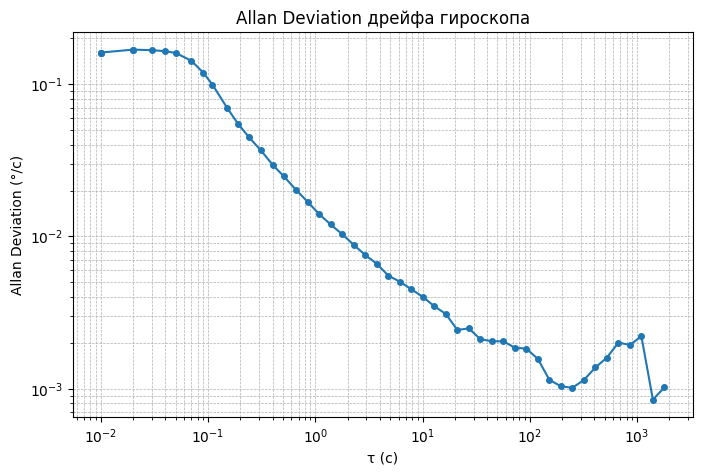

In [82]:
# 2.6. Вычисляем Allan deviation для временного ряда rate
times = dr['time'].values
rates = dr['rate'].values
dt = np.mean(np.diff(times))  # предполагаем, что шаг равен среднему при одинаковом дискретизации

taus, adev = allan_deviation(rates - np.mean(rates), dt)

# Строим график Allan deviation в лог-лог масштабе
plt.figure(figsize=(8, 5))
plt.loglog(taus, adev, 'o-', markersize=4)
plt.xlabel('τ (с)')
plt.ylabel('Allan Deviation (°/с)')
plt.title('Allan Deviation дрейфа гироскопа')
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.show()


#### 2.7. Полиномиальная аппроксимация Allan deviation (стандарт IEEE 1431)

Согласно IEEE 1431, на графике Allan deviation в лог-лог масштабе выделяются участки:
- **ARW (Angle Random Walk):** наклон \(-1/2\) на малых τ.
- **Bias Instability:** плоский участок, минимум Allan deviation.
- **RRW (Rate Random Walk):** наклон \(+1/2\) на больших τ.

Чтобы выделить эти параметры, выполнем полиномиальную аппроксимацию степени 6 (рекомендуется 5–7) в лог-лог пространстве:

\[
\log_{10} \sigma(τ) = c_0 + c_1 \log_{10}(τ) + c_2 [\log_{10}(τ)]^2 + \dots + c_n [\log_{10}(τ)]^n.
\]

После подбора коэффициентов полинома можно:
- Вычислить ARW как значение \(\sigma(τ)\) при τ = 1 с.
- Найти Bias Instability как минимум \(\sigma(τ)\) на аппроксимированной кривой.
- RRW вычислить через \(\sigma(τ)\) при большом τ (например, τ = 3600 с) и разделить на \(\sqrt{τ}\).


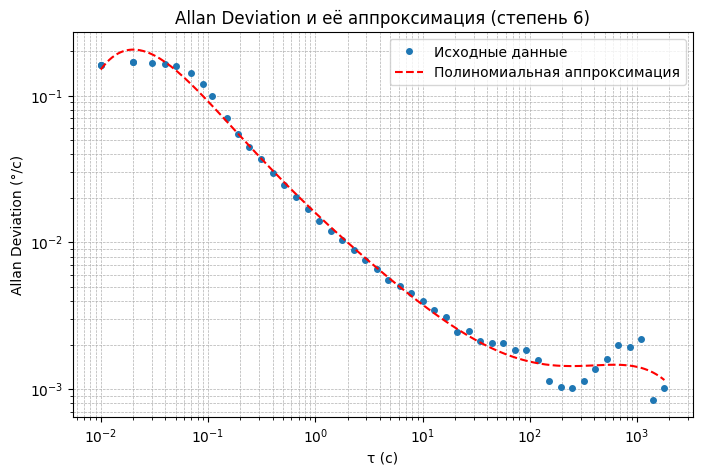

In [83]:
# 2.7. Полиномиальная аппроксимация в лог-лог масштабе
log_taus = np.log10(taus)
log_adev = np.log10(adev)

# Выбираем степень полинома (например, 6)
degree = 6
coeffs = np.polyfit(log_taus, log_adev, degree)
poly = np.poly1d(coeffs)

# Строим аппроксимированную кривую
taus_fit = np.logspace(np.log10(taus.min()), np.log10(taus.max()), 200)
log_adev_fit = poly(np.log10(taus_fit))
adev_fit = 10 ** log_adev_fit

plt.figure(figsize=(8, 5))
plt.loglog(taus, adev, 'o', label='Исходные данные', markersize=4)
plt.loglog(taus_fit, adev_fit, 'r--', label='Полиномиальная аппроксимация')
plt.xlabel('τ (с)')
plt.ylabel('Allan Deviation (°/с)')
plt.title(f'Allan Deviation и её аппроксимация (степень {degree})')
plt.legend()
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.show()


#### 2.8. Извлечение параметров ARW, Bias Instability и RRW

1. **ARW (Angle Random Walk):**  
   Оценивается как значение \(\sigma(τ)\) при \(τ = 1\) с:  
   \[ ARW = \sigma(1\,\text{с}). \]

2. **Bias Instability:**  
   Это минимальное значение \(\sigma(τ)\) на аппроксимированной или исходной кривой.

3. **Rate Random Walk (RRW):**  
   На больших τ область с наклоном \(+\tfrac{1}{2}\). RRW можно оценить, взяв значение \(\sigma(τ)\) при \(τ = 3600\) с и разделив на \(\sqrt{τ}\):  
   \[\; RRW = \frac{\sigma(τ)}{\sqrt{τ}}.\]


In [84]:
# 2.8. Определяем ARW, Bias Instability и RRW

# 1. ARW = sigma(1 s)
adev_at_1s = np.interp(1.0, taus, adev)  # интерполируем до τ = 1 с
ARW = adev_at_1s  # °/√s

# 2. Bias Instability = минимум sigma(τ)
BI = adev.min()

# 3. RRW: возьмем τ = 3600 с (1 час)
tau_large = 3600.0
adev_at_tau_large = np.interp(tau_large, taus_fit, adev_fit)
RRW = adev_at_tau_large / np.sqrt(tau_large)

print(f"ARW (Angle Random Walk): {ARW:.6e} °/√s")
print(f"Bias Instability: {BI:.6e} °/с")
print(f"Rate Random Walk (RRW): {RRW:.6e} °/с/√Hz")  # условные единицы


ARW (Angle Random Walk): 1.505715e-02 °/√s
Bias Instability: 8.480140e-04 °/с
Rate Random Walk (RRW): 1.921687e-05 °/с/√Hz


In [85]:
print(f"Масштабный коэффициент (по ~10% центральных скоростей): {scale_factor_mV_per_dps:.3f} мВ/(°/с)")
print(f"Нелинейность МК: {nonlinearity_pct:.3f} %")
print(f"Несимметричность МК: {asymmetry_pct:.3f} %")
print(f"Смещение нуля (Bias_0) по малому участку: {bias_zero_small:.6f} °/с")
print(f"Смещение нуля по дрейфу: {bias_drift:.6f} °/с")
print(f"Тренд дрейфа: {trend_dph2:.6f} °/ч/ч")
print(f"ARW (Angle Random Walk): {ARW:.6e} °/√s")
print(f"Bias Instability: {BI:.6e} °/с")
print(f"Rate Random Walk (RRW): {RRW:.6e} °/с/√Hz")

Масштабный коэффициент (по ~10% центральных скоростей): -6.219 мВ/(°/с)
Нелинейность МК: 0.038 %
Несимметричность МК: 0.136 %
Смещение нуля (Bias_0) по малому участку: -404.696153 °/с
Смещение нуля по дрейфу: -0.047079 °/с
Тренд дрейфа: -8.145627 °/ч/ч
ARW (Angle Random Walk): 1.505715e-02 °/√s
Bias Instability: 8.480140e-04 °/с
Rate Random Walk (RRW): 1.921687e-05 °/с/√Hz
